# Rise Over Run: Understanding Gradients and Derivatives

Welcome to this educational notebook on **gradients** and the foundational concepts of calculus! This notebook will help you understand how calculus describes the relationship between functions and changes in their variables.

## Learning Objectives
By the end of this notebook, you will understand:
- What gradient (slope) means and how to visualize it
- The concept of local gradient and tangent lines
- How derivatives describe rates of change
- The relationship between position, speed, acceleration, and jerk
- How to interpret and create derivative functions graphically
- The inverse relationship between derivatives and anti-derivatives (integrals)

## Key Insight
**Calculus is simply a set of tools for describing the relationship between a function and the change in its variables.**

## Understanding Gradient (Rise Over Run)

### What is Gradient?
**Gradient** is simply "rise over run" - how much a function goes up (or down) for a given horizontal distance.

$$\text{Gradient} = \frac{\text{Rise}}{\text{Run}} = \frac{\text{Change in y}}{\text{Change in x}} = \frac{\Delta y}{\Delta x}$$

### Gradient Tells Us About Change
- **Positive gradient**: Function is increasing (going upward)
- **Zero gradient**: Function is constant (flat/horizontal)
- **Negative gradient**: Function is decreasing (going downward)
- **Steep gradient**: Function is changing rapidly
- **Gentle gradient**: Function is changing slowly

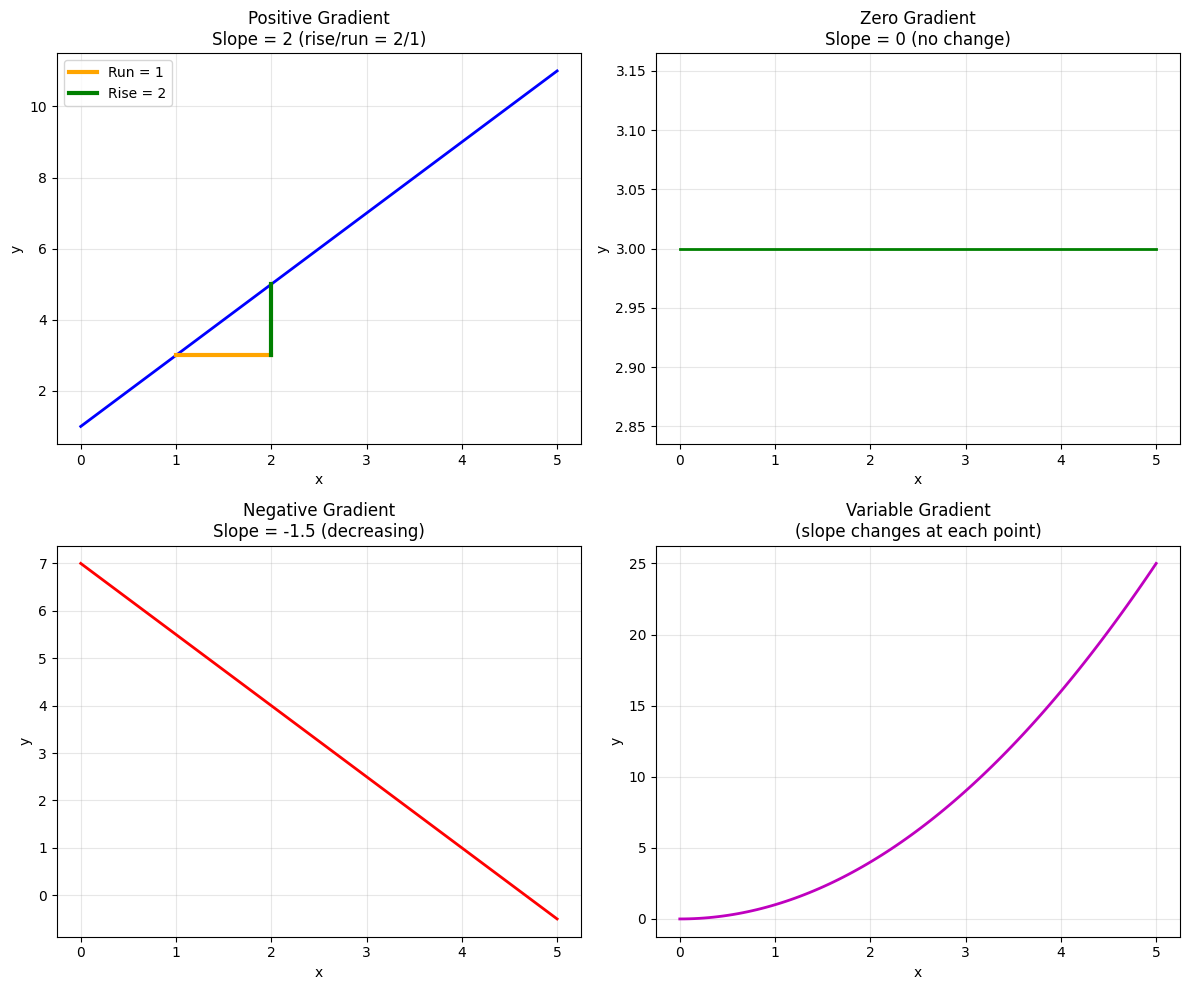

Key Observations:
• Straight lines have constant gradient
• Curved lines have variable gradient (changes at each point)
• This is where calculus becomes essential!


In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate different types of gradients
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Example 1: Positive gradient (constant)
x1 = np.linspace(0, 5, 100)
y1 = 2 * x1 + 1  # slope = 2

axes[0,0].plot(x1, y1, 'b-', linewidth=2)
axes[0,0].set_title('Positive Gradient\nSlope = 2 (rise/run = 2/1)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('y')

# Show rise over run visually
axes[0,0].plot([1, 2], [3, 3], 'orange', linewidth=3, label='Run = 1')
axes[0,0].plot([2, 2], [3, 5], 'green', linewidth=3, label='Rise = 2')
axes[0,0].legend()

# Example 2: Zero gradient (constant function)
x2 = np.linspace(0, 5, 100)
y2 = np.ones_like(x2) * 3  # slope = 0

axes[0,1].plot(x2, y2, 'g-', linewidth=2)
axes[0,1].set_title('Zero Gradient\nSlope = 0 (no change)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('y')

# Example 3: Negative gradient
x3 = np.linspace(0, 5, 100)
y3 = -1.5 * x3 + 7  # slope = -1.5

axes[1,0].plot(x3, y3, 'r-', linewidth=2)
axes[1,0].set_title('Negative Gradient\nSlope = -1.5 (decreasing)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('y')

# Example 4: Variable gradient (curved function)
x4 = np.linspace(0, 5, 100)
y4 = x4**2  # slope changes with x

axes[1,1].plot(x4, y4, 'm-', linewidth=2)
axes[1,1].set_title('Variable Gradient\n(slope changes at each point)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel('y')

plt.tight_layout()
plt.show()

print("Key Observations:")
print("• Straight lines have constant gradient")
print("• Curved lines have variable gradient (changes at each point)")
print("• This is where calculus becomes essential!")

## The Classic Example: Car Speed vs Time

Let's explore the main example from the lecture - a car's speed changing over time. This will help us understand:
- How to interpret graphs of functions
- What gradient means in real-world contexts
- How calculus extracts information from functions

### What the Speed-Time Graph Tells Us
- **Not a horizontal line** → Speed is not constant
- **Initially rising** → Car is accelerating (speeding up)
- **Later falling** → Car is decelerating (slowing down)
- **Slope of the line** → Rate of change of speed = **acceleration**

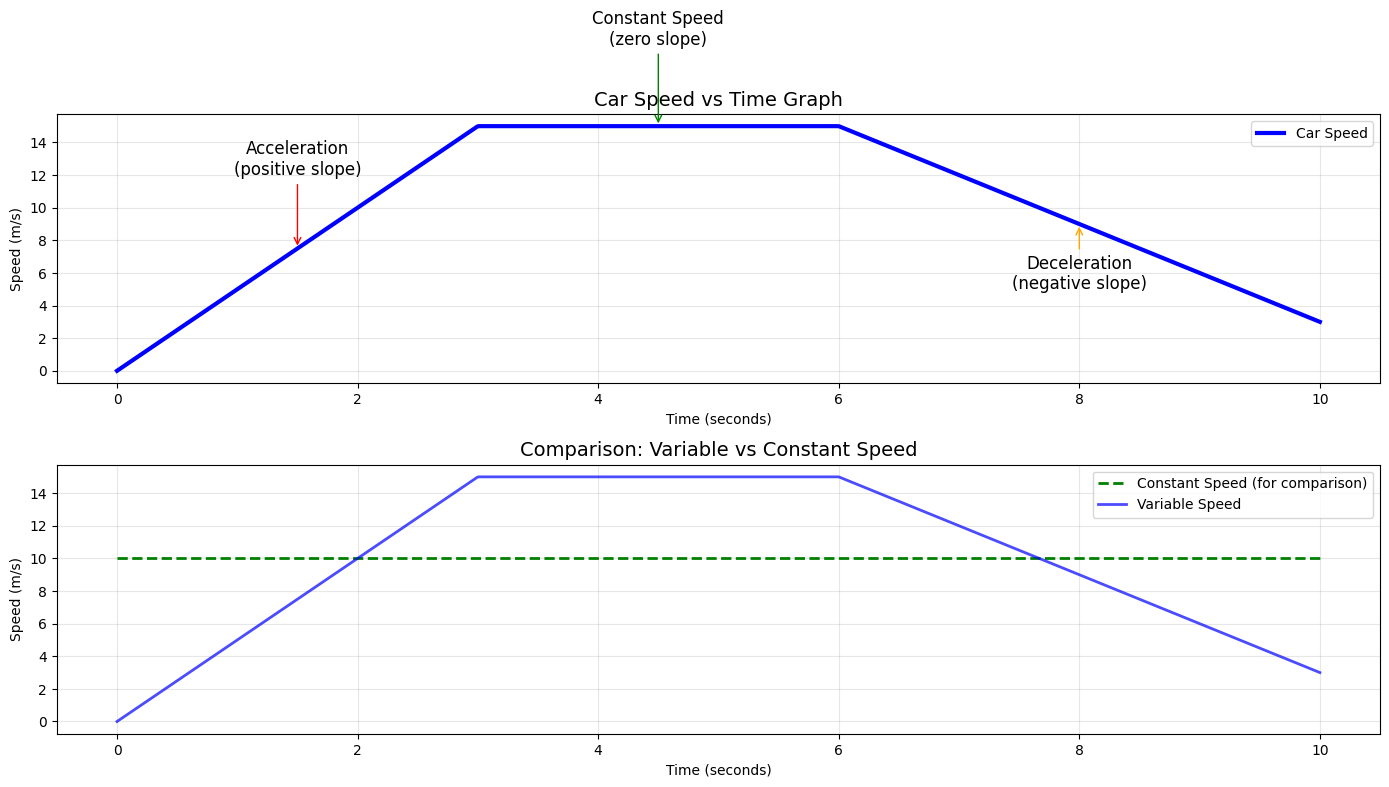

Interpretation of the Speed-Time Graph:
• Horizontal line = constant speed = zero acceleration
• Upward slope = increasing speed = positive acceleration
• Downward slope = decreasing speed = negative acceleration (deceleration)
• Steeper slope = greater rate of change = higher acceleration magnitude


In [3]:
# Create the car speed vs time example
time = np.linspace(0, 10, 1000)

# Define a realistic speed function
# Initially accelerating, then constant, then decelerating
def car_speed(t):
    if isinstance(t, np.ndarray):
        speed = np.zeros_like(t)
        for i, time_val in enumerate(t):
            if time_val <= 3:
                # Acceleration phase: speed increases
                speed[i] = 5 * time_val
            elif time_val <= 6:
                # Constant speed phase
                speed[i] = 15
            else:
                # Deceleration phase: speed decreases
                speed[i] = 15 - 3 * (time_val - 6)
                speed[i] = max(speed[i], 0)  # Don't go below 0
        return speed
    else:
        if t <= 3:
            return 5 * t
        elif t <= 6:
            return 15
        else:
            return max(15 - 3 * (t - 6), 0)

speed = car_speed(time)

# Create the plot
plt.figure(figsize=(14, 8))

# Main speed vs time plot
plt.subplot(2, 1, 1)
plt.plot(time, speed, 'b-', linewidth=3, label='Car Speed')
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Car Speed vs Time Graph', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Add annotations to explain different phases
plt.annotate('Acceleration\n(positive slope)', xy=(1.5, 7.5), xytext=(1.5, 12),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, ha='center')
plt.annotate('Constant Speed\n(zero slope)', xy=(4.5, 15), xytext=(4.5, 20),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=12, ha='center')
plt.annotate('Deceleration\n(negative slope)', xy=(8, 9), xytext=(8, 5),
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=12, ha='center')

# Comparison with constant speed
plt.subplot(2, 1, 2)
constant_speed = np.ones_like(time) * 10  # Constant 10 m/s
plt.plot(time, constant_speed, 'g--', linewidth=2, label='Constant Speed (for comparison)')
plt.plot(time, speed, 'b-', linewidth=2, label='Variable Speed', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Comparison: Variable vs Constant Speed', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("Interpretation of the Speed-Time Graph:")
print("• Horizontal line = constant speed = zero acceleration")
print("• Upward slope = increasing speed = positive acceleration") 
print("• Downward slope = decreasing speed = negative acceleration (deceleration)")
print("• Steeper slope = greater rate of change = higher acceleration magnitude")

## Local Gradient and Tangent Lines

For curved functions, the gradient changes at every point. We need to understand:

### Local Gradient
**Local gradient** is the gradient at a specific point on a curve, not over a range.

### Tangent Line
A **tangent line** is a straight line that:
- Touches the curve at exactly one point
- Has the same gradient as the curve at that point
- Shows us the instantaneous rate of change

### Key Insight
> **Acceleration is defined as the local gradient of a speed-time graph.**

This means: $\text{Acceleration} = \frac{d(\text{speed})}{d(\text{time})}$

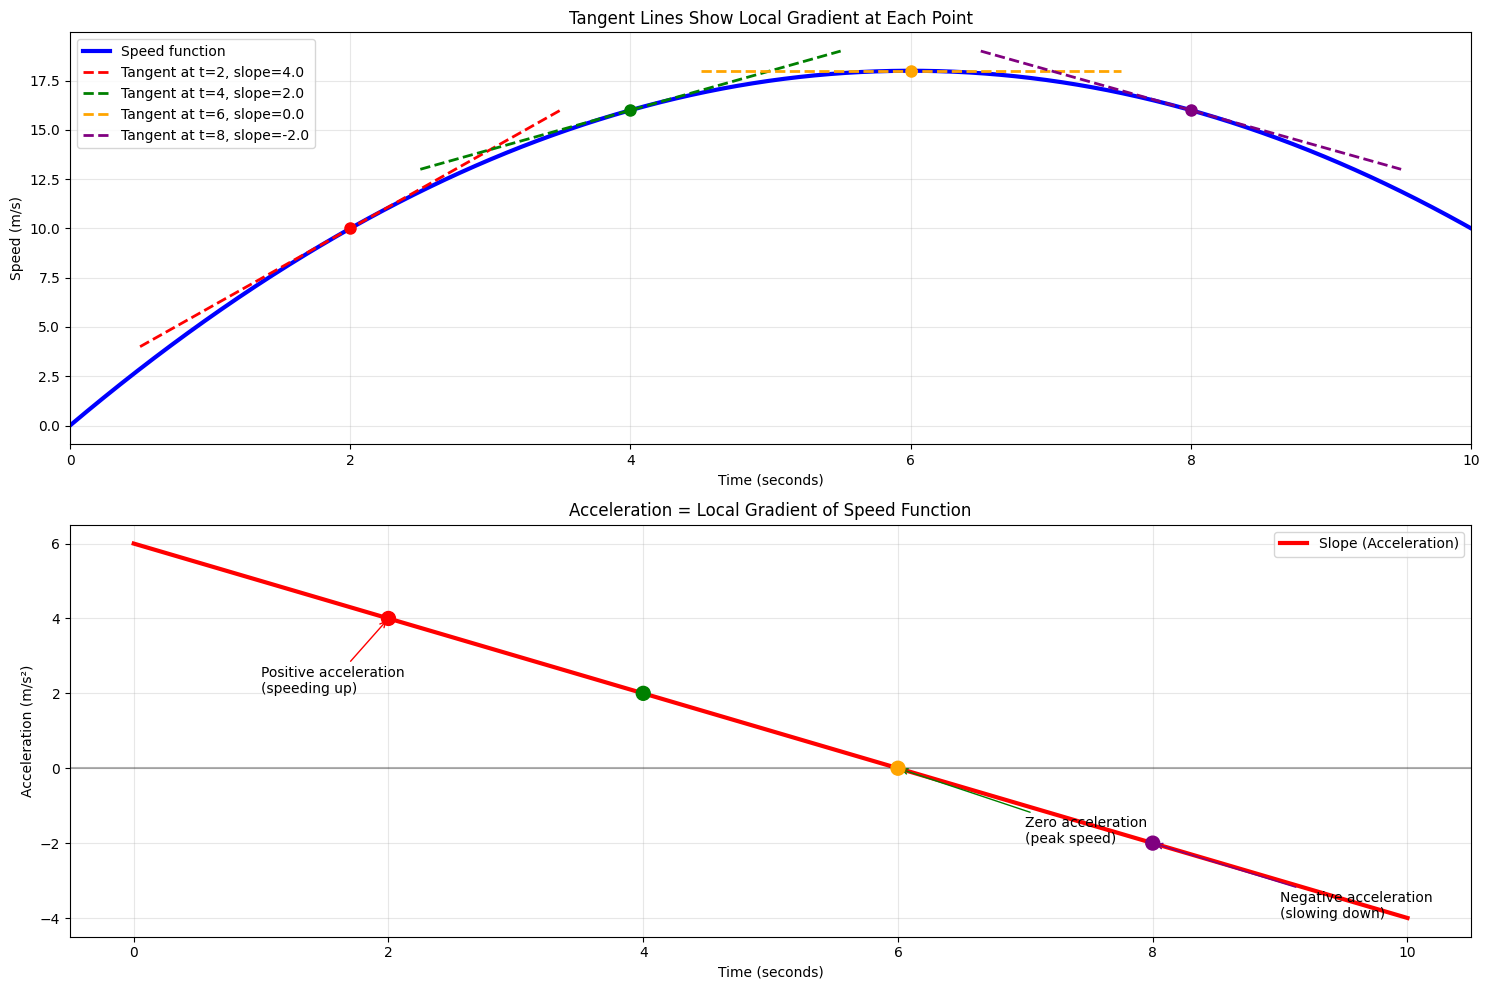

Key Insights:
• Each tangent line shows the instantaneous rate of change
• The slope of the tangent = acceleration at that moment
• Positive slope = acceleration, negative slope = deceleration
• Zero slope = constant speed (no acceleration)


In [4]:
# Demonstrate tangent lines and local gradients
def smooth_speed_function(t):
    """A smooth function representing car speed"""
    return -0.5 * t**2 + 6 * t

# Create a smooth curve
t_smooth = np.linspace(0, 10, 1000)
speed_smooth = smooth_speed_function(t_smooth)

# Points where we'll draw tangent lines
tangent_points = [2, 4, 6, 8]

plt.figure(figsize=(15, 10))

# Main plot with tangent lines
plt.subplot(2, 1, 1)
plt.plot(t_smooth, speed_smooth, 'b-', linewidth=3, label='Speed function')

# Calculate and draw tangent lines
colors = ['red', 'green', 'orange', 'purple']
for i, t_point in enumerate(tangent_points):
    # Calculate derivative (slope) at this point
    # For f(t) = -0.5t² + 6t, derivative is f'(t) = -t + 6
    slope = -t_point + 6
    speed_at_point = smooth_speed_function(t_point)
    
    # Create tangent line: y - y₁ = m(x - x₁)
    t_tangent = np.linspace(t_point - 1.5, t_point + 1.5, 100)
    tangent_line = speed_at_point + slope * (t_tangent - t_point)
    
    # Plot the tangent line
    plt.plot(t_tangent, tangent_line, colors[i], linewidth=2, linestyle='--',
             label=f'Tangent at t={t_point}, slope={slope:.1f}')
    
    # Mark the point
    plt.plot(t_point, speed_at_point, 'o', color=colors[i], markersize=8)

plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Tangent Lines Show Local Gradient at Each Point')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 10)

# Show how slope changes
plt.subplot(2, 1, 2)
t_fine = np.linspace(0, 10, 100)
slopes = -t_fine + 6  # Derivative of our function

plt.plot(t_fine, slopes, 'r-', linewidth=3, label='Slope (Acceleration)')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.scatter(tangent_points, [-t + 6 for t in tangent_points], 
           color=['red', 'green', 'orange', 'purple'], s=100, zorder=5)

# Annotations
plt.annotate('Positive acceleration\n(speeding up)', xy=(2, 4), xytext=(1, 2),
            arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate('Zero acceleration\n(peak speed)', xy=(6, 0), xytext=(7, -2),
            arrowprops=dict(arrowstyle='->', color='green'))
plt.annotate('Negative acceleration\n(slowing down)', xy=(8, -2), xytext=(9, -4),
            arrowprops=dict(arrowstyle='->', color='purple'))

plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration = Local Gradient of Speed Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Insights:")
print("• Each tangent line shows the instantaneous rate of change")
print("• The slope of the tangent = acceleration at that moment")
print("• Positive slope = acceleration, negative slope = deceleration")
print("• Zero slope = constant speed (no acceleration)")

## The Essence of Calculus: Creating Derivative Functions

### What We Just Did
By recording the slope of tangent lines at every point, we created an entirely new function! This is the **essence of calculus**.

### Derivative Definition
The **derivative** of a function is a new function that tells us the slope (rate of change) at every point of the original function.

If we have a function $f(t)$, its derivative is written as:
- $f'(t)$ (read as "f prime of t")
- $\frac{df}{dt}$ (read as "d f, d t")

### The Process
1. **Start with a function** (e.g., speed vs time)
2. **Find the slope at every point** (using tangent lines)
3. **Plot these slopes** to create a new function (the derivative)
4. **This new function shows rates of change**

### Real-World Meaning
- Speed function → Acceleration function (first derivative)
- Acceleration function → Jerk function (second derivative)
- Position function → Speed function (first derivative)

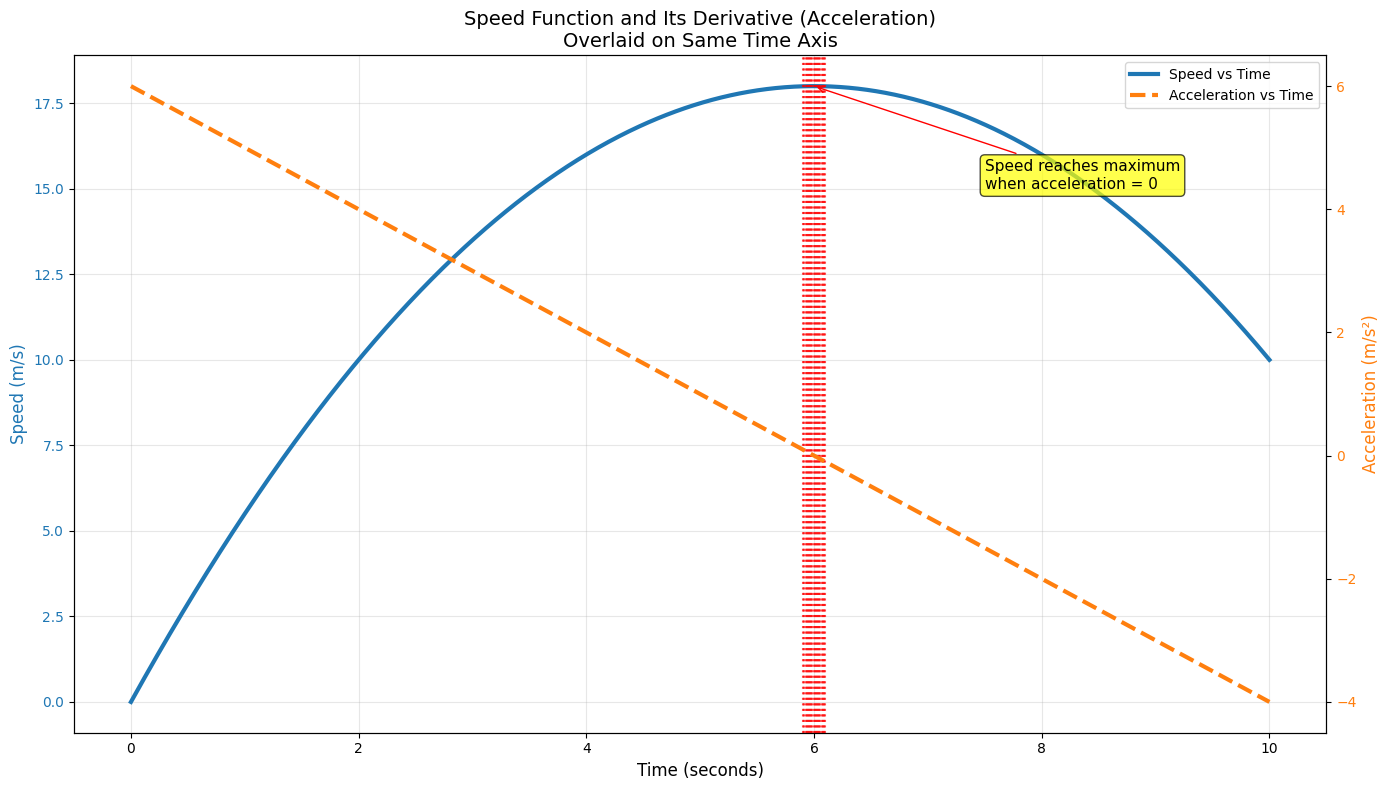

Understanding Units and Scaling:
SPEED:
• Vertical axis: distance per time (m/s)
• Blue line shows speed values

ACCELERATION:
• Vertical axis: distance per time squared (m/s²)
• Orange line shows acceleration values

KEY INSIGHT:
• Different units allow us to scale the lines vertically
• What matters is the SHAPE and where functions cross zero
• Points where acceleration = 0 correspond to flat spots on speed curve
• This is the fundamental relationship between a function and its derivative!


In [5]:
# Create the complete speed → acceleration demonstration
# Using the same smooth function from before

t_range = np.linspace(0, 10, 1000)
speed_func = -0.5 * t_range**2 + 6 * t_range
acceleration_func = -t_range + 6  # Derivative of speed function

# Create overlaid plot as mentioned in the lecture
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot speed function
color1 = 'tab:blue'
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Speed (m/s)', color=color1, fontsize=12)
line1 = ax1.plot(t_range, speed_func, color=color1, linewidth=3, label='Speed vs Time')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create second y-axis for acceleration
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Acceleration (m/s²)', color=color2, fontsize=12)
line2 = ax2.plot(t_range, acceleration_func, color=color2, linewidth=3, 
                linestyle='--', label='Acceleration vs Time')
ax2.tick_params(axis='y', labelcolor=color2)

# Add vertical lines where acceleration crosses zero
zero_crossings = t_range[np.where(np.abs(acceleration_func) < 0.1)[0]]
for crossing in zero_crossings:
    ax1.axvline(x=crossing, color='red', linestyle=':', alpha=0.7)

# Add annotations
ax1.annotate('Speed reaches maximum\nwhen acceleration = 0', 
            xy=(6, 18), xytext=(7.5, 15),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.title('Speed Function and Its Derivative (Acceleration)\nOverlaid on Same Time Axis', fontsize=14)

# Create legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Demonstrate the key insight about units
print("Understanding Units and Scaling:")
print("="*50)
print("SPEED:")
print("• Vertical axis: distance per time (m/s)")
print("• Blue line shows speed values")
print()
print("ACCELERATION:")  
print("• Vertical axis: distance per time squared (m/s²)")
print("• Orange line shows acceleration values")
print()
print("KEY INSIGHT:")
print("• Different units allow us to scale the lines vertically")
print("• What matters is the SHAPE and where functions cross zero")
print("• Points where acceleration = 0 correspond to flat spots on speed curve")
print("• This is the fundamental relationship between a function and its derivative!")

## Higher-Order Derivatives: Understanding "Jerk"

### Beyond the First Derivative
We can continue taking derivatives! Each new derivative tells us about different aspects of change:

### The Derivative Chain
1. **Position** → Speed (1st derivative)
2. **Speed** → Acceleration (1st derivative of speed, 2nd derivative of position)  
3. **Acceleration** → Jerk (1st derivative of acceleration, 3rd derivative of position)

### What is "Jerk"?
**Jerk** is the rate of change of acceleration. It describes how quickly acceleration itself is changing.

- **High jerk** = acceleration changes rapidly (uncomfortable, jerky motion)
- **Low jerk** = acceleration changes smoothly (comfortable motion)
- **Zero jerk** = constant acceleration (steady, predictable motion)

### Why "Jerk" Matters
Think about riding in a car:
- **Smooth acceleration** = low jerk = comfortable
- **Sudden acceleration changes** = high jerk = uncomfortable, "jerky" feeling

This is exactly why it's called "jerk"!

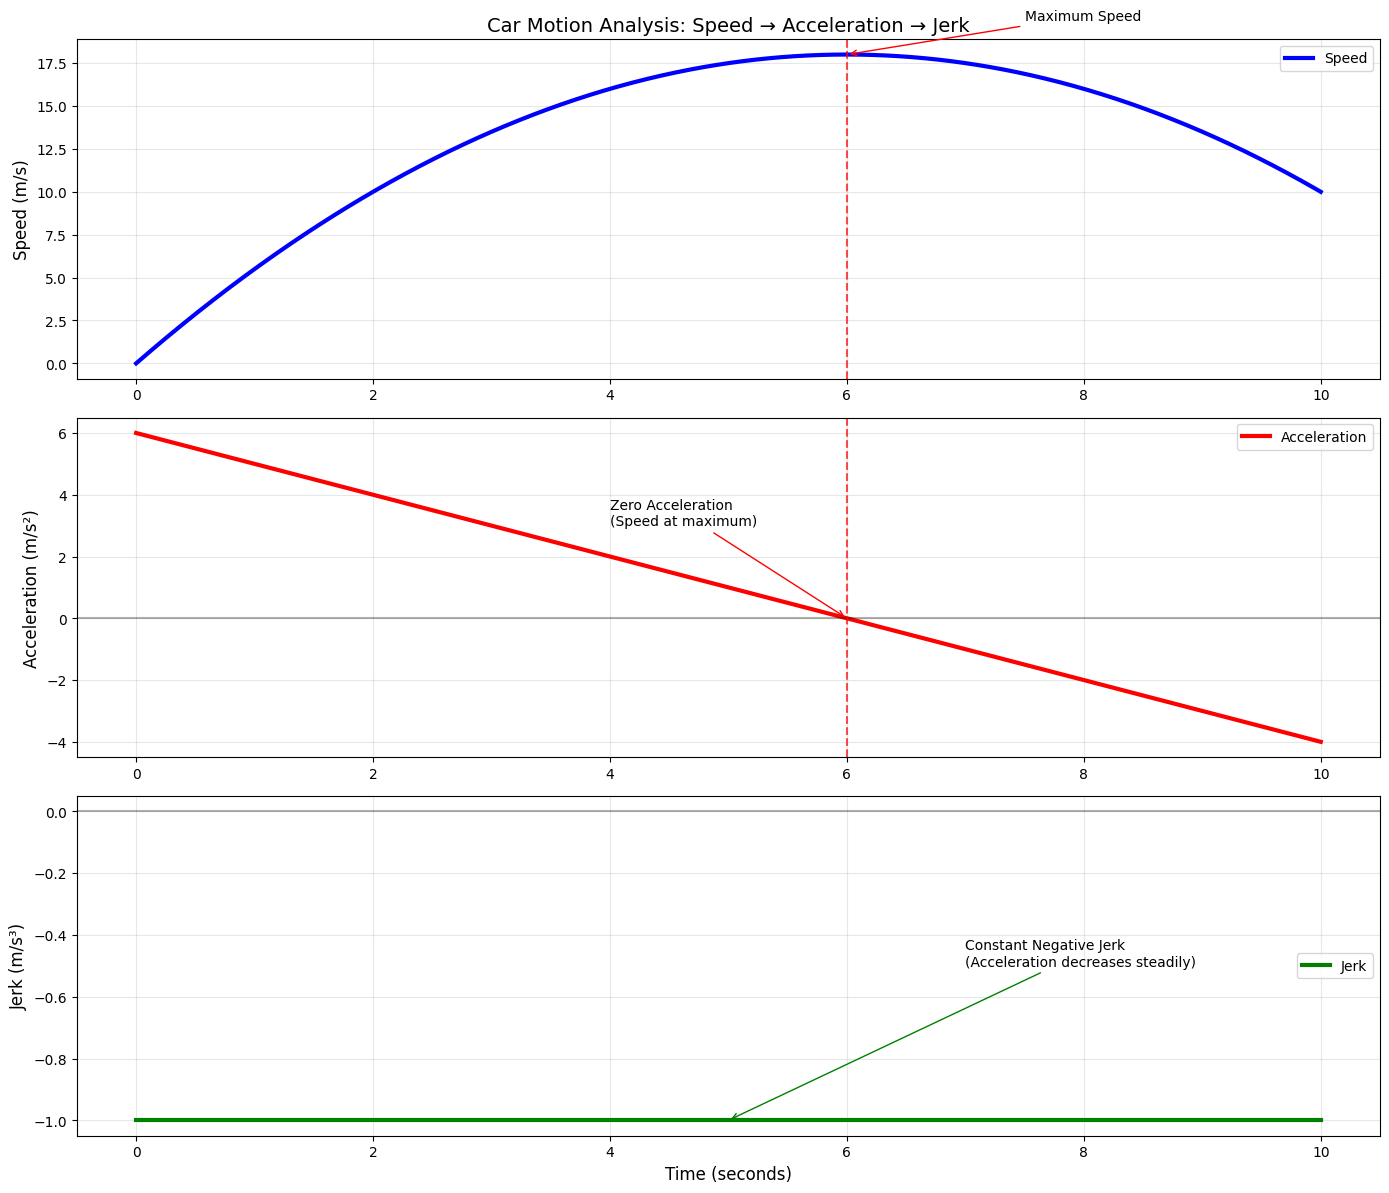

Motion Analysis Summary:
SPEED GRAPH:
• Starts at 0, increases, reaches maximum at t=6, then decreases
• Shape: upside-down parabola

ACCELERATION GRAPH:
• Starts positive (speeding up)
• Decreases linearly
• Becomes zero at t=6 (maximum speed)
• Becomes negative (slowing down)

JERK GRAPH:
• Constant at -1 m/s³
• Negative jerk means acceleration is constantly decreasing
• This creates the smooth, predictable motion pattern

REAL-WORLD INTERPRETATION:
• This represents a car that smoothly accelerates then smoothly decelerates
• Constant jerk = comfortable ride (no sudden changes)
• Zero jerk would mean constant acceleration (less realistic)
• High variable jerk would mean jerky, uncomfortable motion


In [8]:
# Demonstrate the complete derivative chain: Speed → Acceleration → Jerk

# Using our smooth function: f(t) = -0.5t² + 6t
t = np.linspace(0, 10, 1000)

# Original function (Speed)
speed = -0.5 * t**2 + 6 * t

# First derivative (Acceleration)
acceleration = -t + 6

# Second derivative (Jerk) 
# Since acceleration = -t + 6, the derivative of this is -1 (constant)
jerk = np.ones_like(t) * (-1)  # Constant jerk of -1

# Create three-panel plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Speed plot
axes[0].plot(t, speed, 'b-', linewidth=3, label='Speed')
axes[0].set_ylabel('Speed (m/s)', fontsize=12)
axes[0].set_title('Car Motion Analysis: Speed → Acceleration → Jerk', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Mark important points
max_speed_time = 6
axes[0].axvline(x=max_speed_time, color='red', linestyle='--', alpha=0.7)
axes[0].annotate('Maximum Speed', xy=(max_speed_time, 18), xytext=(7.5, 20),
                arrowprops=dict(arrowstyle='->', color='red'))

# Acceleration plot  
axes[1].plot(t, acceleration, 'r-', linewidth=3, label='Acceleration')
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_ylabel('Acceleration (m/s²)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Mark zero crossing
axes[1].axvline(x=max_speed_time, color='red', linestyle='--', alpha=0.7)
axes[1].annotate('Zero Acceleration\n(Speed at maximum)', 
                xy=(max_speed_time, 0), xytext=(4, 3),
                arrowprops=dict(arrowstyle='->', color='red'))

# Jerk plot
axes[2].plot(t, jerk, 'g-', linewidth=3, label='Jerk')
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].set_ylabel('Jerk (m/s³)', fontsize=12)
axes[2].set_xlabel('Time (seconds)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# Annotate constant jerk
axes[2].annotate('Constant Negative Jerk\n(Acceleration decreases steadily)', 
                xy=(5, -1), xytext=(7, -0.5),
                arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

# Compare different motion scenarios
print("Motion Analysis Summary:")
print("="*50)
print("SPEED GRAPH:")
print("• Starts at 0, increases, reaches maximum at t=6, then decreases")
print("• Shape: upside-down parabola")

print("\nACCELERATION GRAPH:")  
print("• Starts positive (speeding up)")
print("• Decreases linearly")
print("• Becomes zero at t=6 (maximum speed)")
print("• Becomes negative (slowing down)")

print("\nJERK GRAPH:")
print("• Constant at -1 m/s³")
print("• Negative jerk means acceleration is constantly decreasing")
print("• This creates the smooth, predictable motion pattern")

print("\nREAL-WORLD INTERPRETATION:")
print("• This represents a car that smoothly accelerates then smoothly decelerates")
print("• Constant jerk = comfortable ride (no sudden changes)")
print("• Zero jerk would mean constant acceleration (less realistic)")
print("• High variable jerk would mean jerky, uncomfortable motion")

## The Inverse Process: Anti-Derivatives and Integrals

### Going Backwards
So far we've gone from functions to their derivatives. But we can also go backwards!

**Anti-derivative**: Given a derivative function, what was the original function?

### The Inverse Relationship
If we know that speed is the derivative of position, then:
- **Given speed** → We can find **position** (anti-derivative/integral)
- **Given acceleration** → We can find **speed** (anti-derivative/integral)

### Real-World Meaning
- **Speed function** → **Distance traveled** (area under speed curve)
- **Acceleration function** → **Change in speed** (area under acceleration curve)

### Key Insight from the Lecture
> "The anti-derivative of speed represents the distance of the car from its starting position."

This makes sense because:
$$\frac{d(\text{distance})}{d(\text{time})} = \text{speed}$$

So if speed is the derivative of distance, then distance is the anti-derivative of speed!

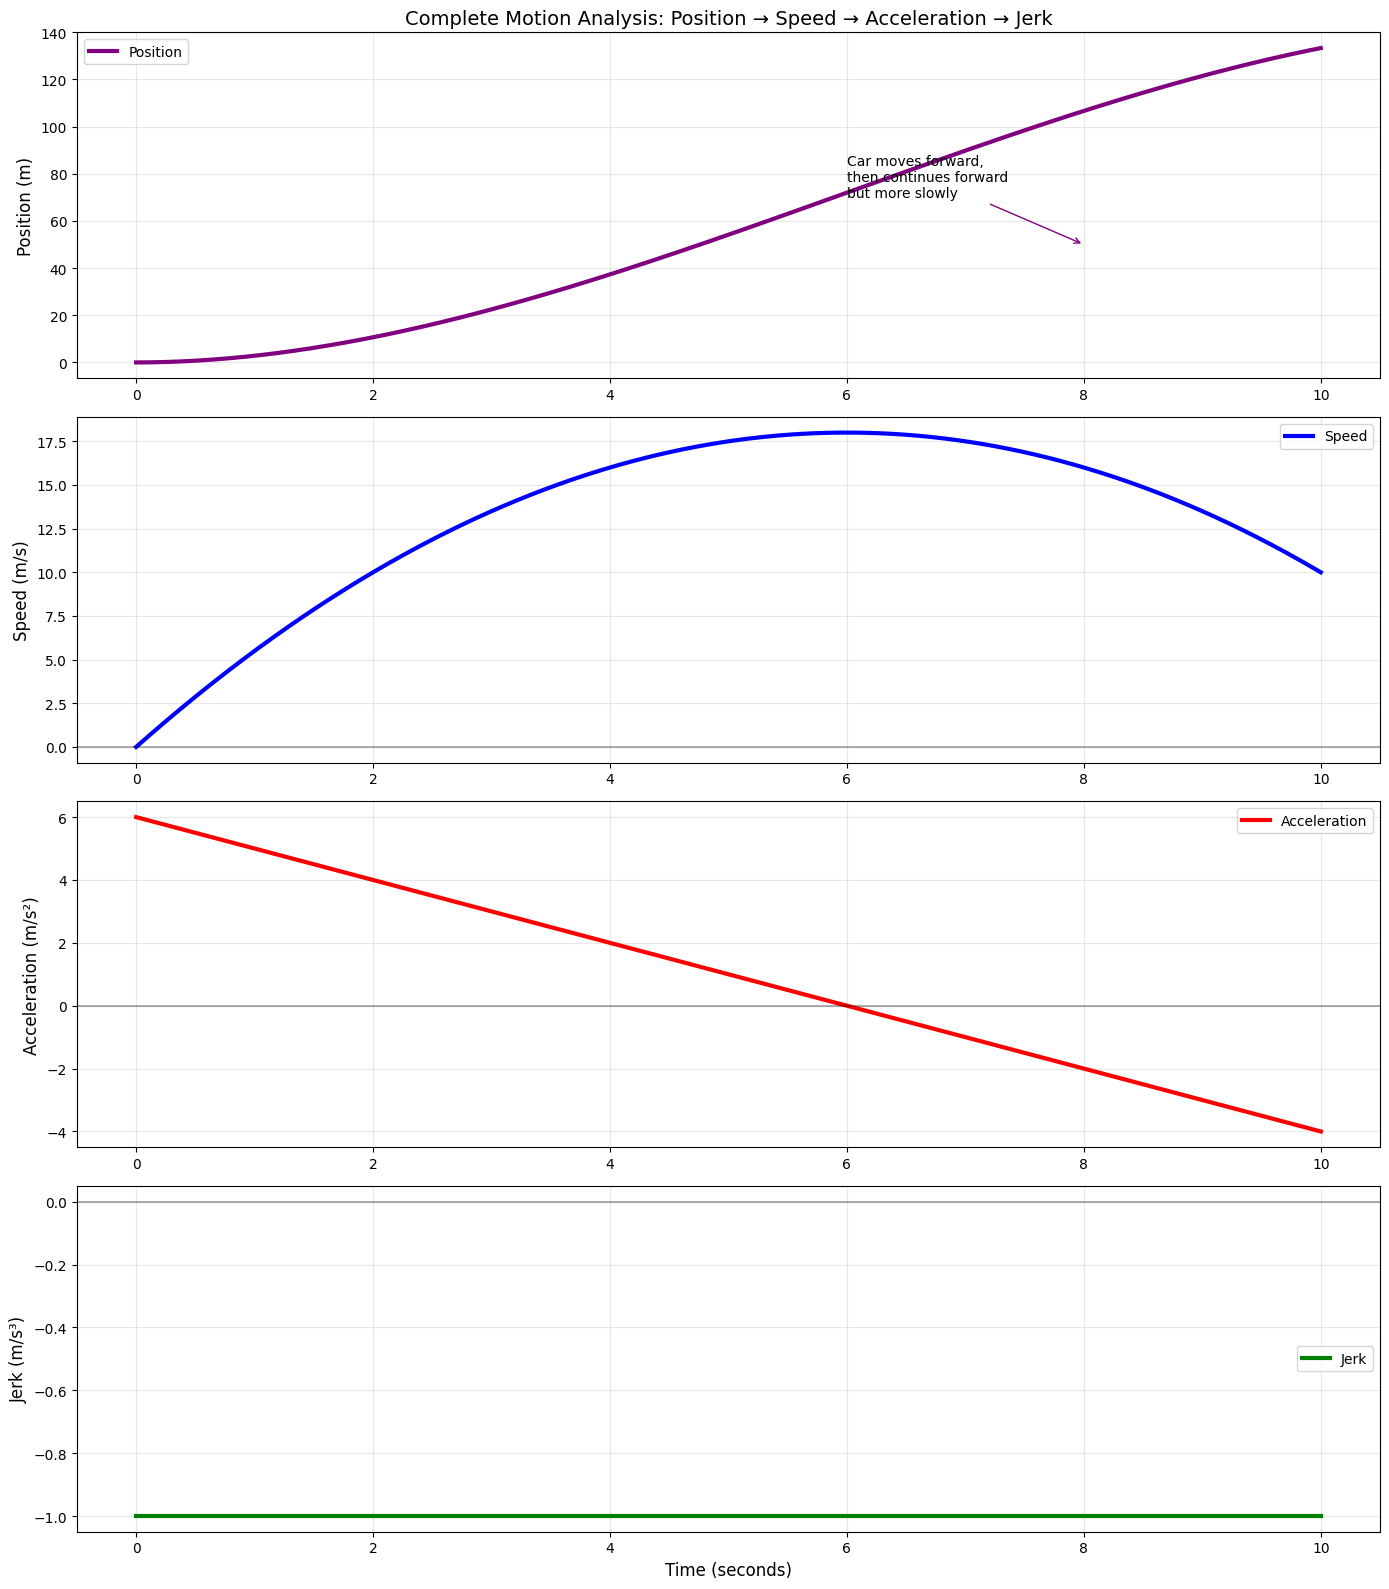

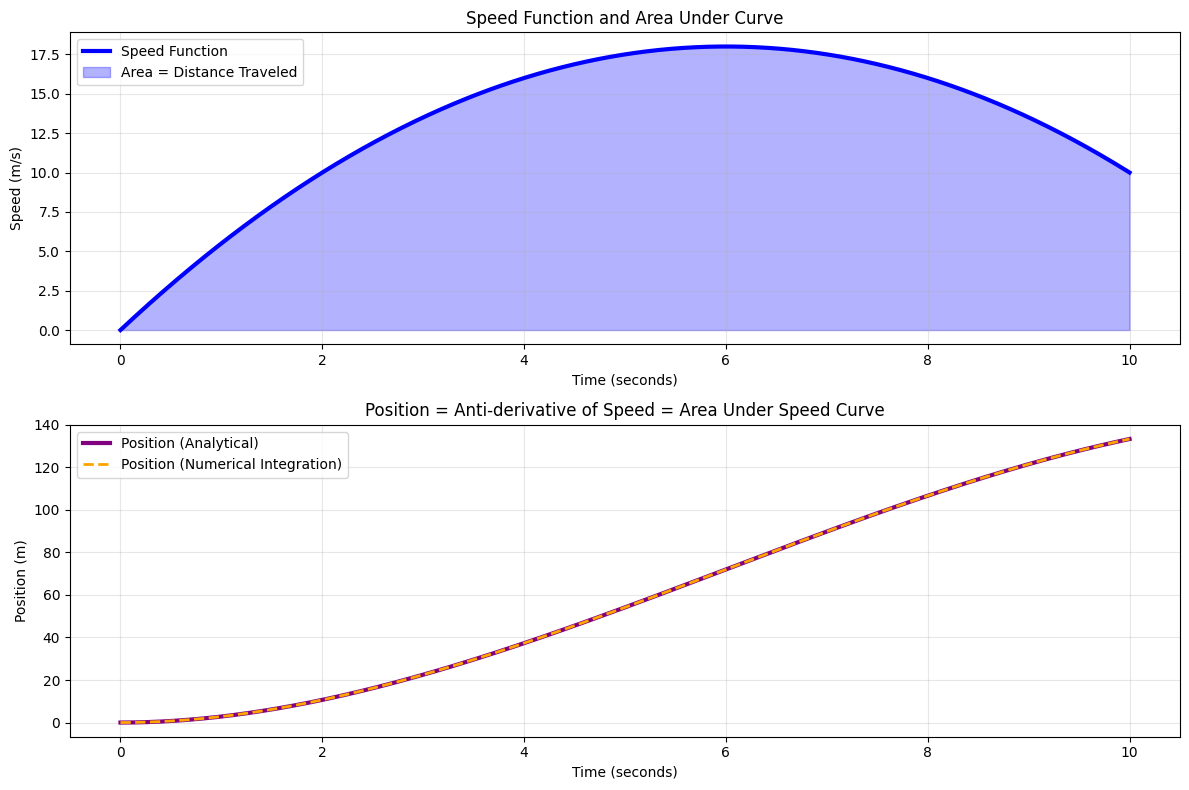

The Derivative-Integral Relationship:
FORWARD (Differentiation):
Position → Speed → Acceleration → Jerk
   d/dt     d/dt        d/dt

BACKWARD (Integration):
Position ← Speed ← Acceleration ← Jerk
   ∫dt      ∫dt        ∫dt

KEY INSIGHTS:
• Position is the anti-derivative of speed
• Speed is the anti-derivative of acceleration
• The area under the speed curve = distance traveled
• Integration and differentiation are inverse operations
• This is the fundamental theorem of calculus!


In [10]:
# Demonstrate anti-derivatives: Speed → Position

# Our speed function: speed(t) = -0.5t² + 6t
# To find position, we need the anti-derivative (integral) of speed

# The anti-derivative of -0.5t² + 6t is:
# ∫(-0.5t² + 6t)dt = -0.5(t³/3) + 6(t²/2) + C = -t³/6 + 3t² + C
# Let's assume starting position is 0, so C = 0

t = np.linspace(0, 10, 1000)
speed = -0.5 * t**2 + 6 * t
position = -(t**3)/6 + 3 * (t**2)  # Anti-derivative of speed

# Also calculate acceleration for complete picture
acceleration = -t + 6

# Create comprehensive motion analysis
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Position plot
axes[0].plot(t, position, 'purple', linewidth=3, label='Position')
axes[0].set_ylabel('Position (m)', fontsize=12)
axes[0].set_title('Complete Motion Analysis: Position → Speed → Acceleration → Jerk', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].annotate('Car moves forward,\nthen continues forward\nbut more slowly', 
                xy=(8, 50), xytext=(6, 70),
                arrowprops=dict(arrowstyle='->', color='purple'))

# Speed plot  
axes[1].plot(t, speed, 'b-', linewidth=3, label='Speed')
axes[1].set_ylabel('Speed (m/s)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Acceleration plot
axes[2].plot(t, acceleration, 'r-', linewidth=3, label='Acceleration') 
axes[2].set_ylabel('Acceleration (m/s²)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Jerk plot
jerk = np.ones_like(t) * (-1)
axes[3].plot(t, jerk, 'g-', linewidth=3, label='Jerk')
axes[3].set_ylabel('Jerk (m/s³)', fontsize=12)
axes[3].set_xlabel('Time (seconds)', fontsize=12)
axes[3].grid(True, alpha=0.3)
axes[3].legend()
axes[3].axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Demonstrate the relationship using numerical integration
from scipy.integrate import cumulative_trapezoid

# Numerical integration to verify our analytical result
position_numerical = cumulative_trapezoid(speed, t, initial=0)

# Compare analytical vs numerical integration
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, speed, 'b-', linewidth=3, label='Speed Function')
plt.fill_between(t, 0, speed, alpha=0.3, color='blue', label='Area = Distance Traveled')
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Speed Function and Area Under Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t, position, 'purple', linewidth=3, label='Position (Analytical)')
plt.plot(t, position_numerical, 'orange', linewidth=2, linestyle='--', 
         label='Position (Numerical Integration)')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('Position = Anti-derivative of Speed = Area Under Speed Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The Derivative-Integral Relationship:")
print("="*50)
print("FORWARD (Differentiation):")
print("Position → Speed → Acceleration → Jerk")
print("   d/dt     d/dt        d/dt")

print("\nBACKWARD (Integration):")  
print("Position ← Speed ← Acceleration ← Jerk")
print("   ∫dt      ∫dt        ∫dt")

print("\nKEY INSIGHTS:")
print("• Position is the anti-derivative of speed")
print("• Speed is the anti-derivative of acceleration") 
print("• The area under the speed curve = distance traveled")
print("• Integration and differentiation are inverse operations")
print("• This is the fundamental theorem of calculus!")

## Key Takeaways: The Foundation of Calculus

### What We've Learned

✅ **Gradient = Rise over Run** - measures how functions change  
✅ **Local gradient** - slope at a specific point using tangent lines  
✅ **Derivatives** - functions that describe rates of change  
✅ **Higher-order derivatives** - rates of change of rates of change  
✅ **Anti-derivatives/Integrals** - the inverse process of differentiation  

### The Complete Picture

```
Position Function
       ↓ (differentiate)
Speed Function  
       ↓ (differentiate)
Acceleration Function
       ↓ (differentiate)  
Jerk Function
```

### Real-World Applications
- **Engineering**: Analyzing motion, vibrations, control systems
- **Physics**: Understanding forces, energy, wave motion
- **Economics**: Marginal costs, rates of change in markets
- **Biology**: Population growth rates, reaction rates
- **Machine Learning**: Optimization, gradient descent

### The Power of Calculus
Even without formal definitions, you can now:
- Interpret slope and rate of change
- Understand the relationship between functions and their derivatives
- Recognize when calculus tools would be useful
- Think about optimization and change analysis

This foundation prepares you for formal differentiation rules and advanced applications!

## Practice Exercises: Test Your Understanding

Try these gradient and derivative questions to solidify your understanding:

### Exercise 1: Interpreting Gradients
Look at these scenarios and describe what the gradient tells you:

a) **Temperature vs altitude graph** has a negative slope  
b) **Bank account balance vs time** has a positive slope  
c) **Speed vs time graph** has zero slope  
d) **Population vs time graph** has an increasing slope  

### Exercise 2: Tangent Line Analysis
If you draw a tangent line to a curve and it has:
- Slope = 5 → What does this mean about the function at that point?
- Slope = 0 → What does this mean about the function at that point?  
- Slope = -3 → What does this mean about the function at that point?

### Exercise 3: Derivative Relationships
Match the physical quantity with its derivative:

| Function | Derivative |
|----------|------------|
| Position | ? |
| Speed | ? |
| Acceleration | ? |

Options: Speed, Acceleration, Jerk

### Exercise 4: Real-World Applications
For each scenario, identify what the derivative would represent:

a) **Stock price vs time** → Derivative = ?  
b) **Water level in tank vs time** → Derivative = ?  
c) **Distance traveled vs time** → Derivative = ?  
d) **Cost of production vs number of items** → Derivative = ?

SOLUTIONS TO PRACTICE EXERCISES

Exercise 1: Interpreting Gradients
-----------------------------------
a) Temperature vs altitude (negative slope):
   → Temperature DECREASES as altitude increases
   → Rate: how many degrees colder per meter higher

b) Bank account vs time (positive slope):
   → Money is being ADDED to account over time
   → Rate: how much money gained per day/month

c) Speed vs time (zero slope):
   → Speed is CONSTANT (not changing)
   → No acceleration - steady motion

d) Population vs time (increasing slope):
   → Population growing at an ACCELERATING rate
   → Not just growing, but growing faster and faster


Exercise 2: Tangent Line Analysis
-----------------------------------
Slope = 5  → Function increasing rapidly (steep upward)
Slope = 0  → Function is flat (local max/min or inflection)
Slope = -3 → Function decreasing rapidly (steep downward)


Exercise 3: Derivative Relationships
-----------------------------------
Position → derivative → Speed
Speed → der

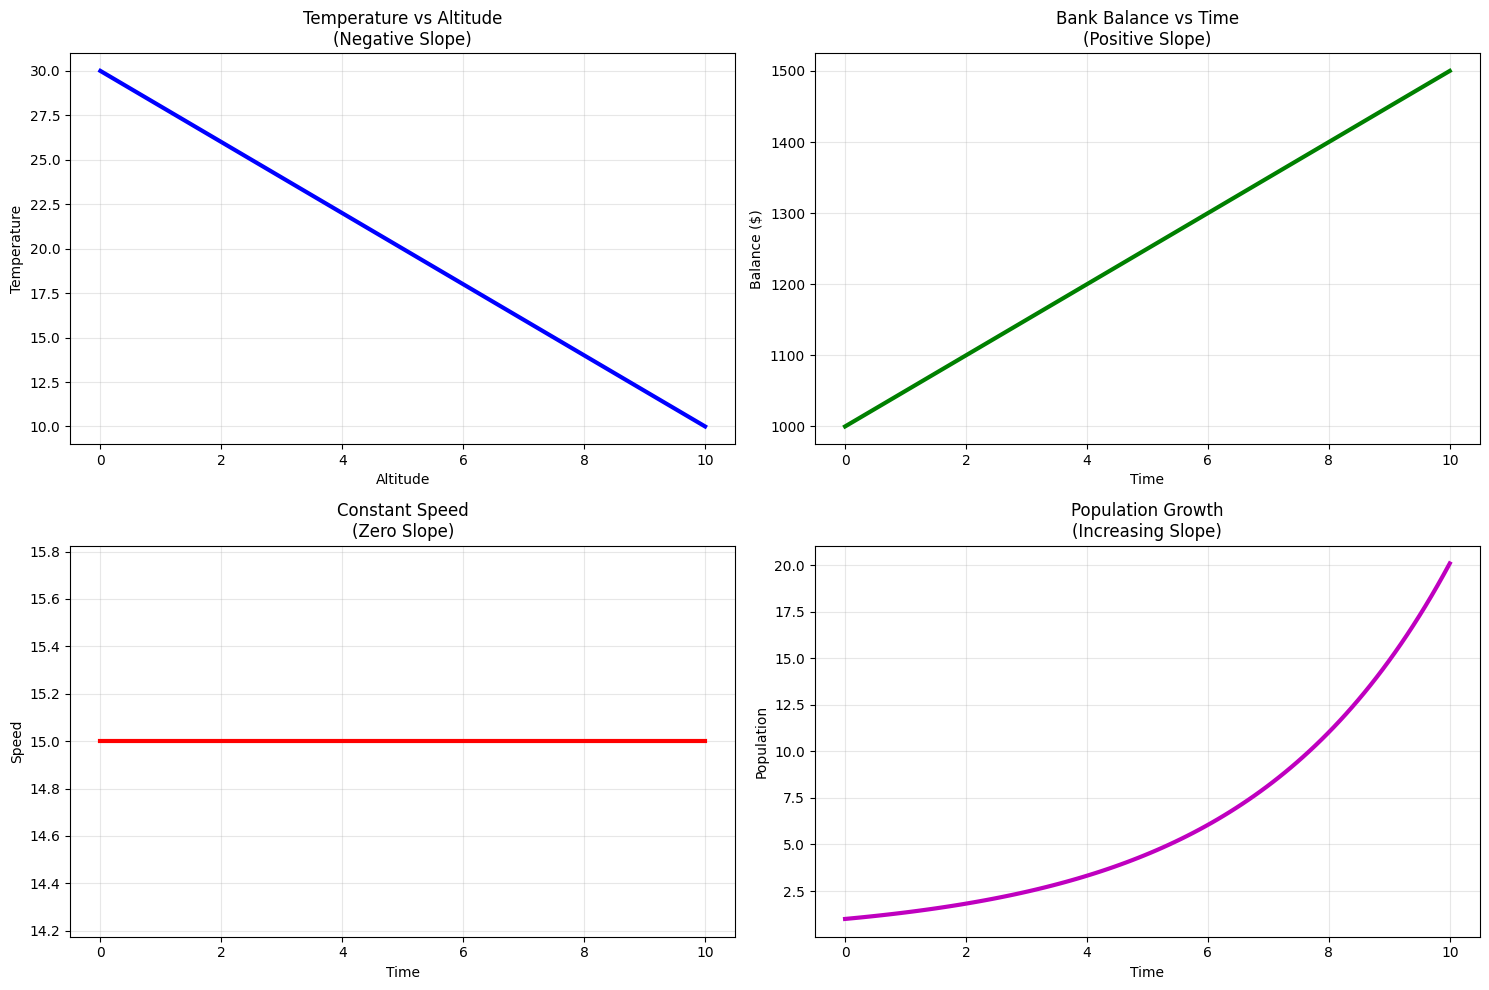

In [11]:
# Solutions to Practice Exercises
print("SOLUTIONS TO PRACTICE EXERCISES")
print("="*50)

print("\nExercise 1: Interpreting Gradients")
print("-" * 35)
print("a) Temperature vs altitude (negative slope):")
print("   → Temperature DECREASES as altitude increases")
print("   → Rate: how many degrees colder per meter higher")

print("\nb) Bank account vs time (positive slope):")
print("   → Money is being ADDED to account over time")  
print("   → Rate: how much money gained per day/month")

print("\nc) Speed vs time (zero slope):")
print("   → Speed is CONSTANT (not changing)")
print("   → No acceleration - steady motion")

print("\nd) Population vs time (increasing slope):")
print("   → Population growing at an ACCELERATING rate")
print("   → Not just growing, but growing faster and faster")

print("\n" + "="*50)

print("\nExercise 2: Tangent Line Analysis")
print("-" * 35)
print("Slope = 5  → Function increasing rapidly (steep upward)")
print("Slope = 0  → Function is flat (local max/min or inflection)")
print("Slope = -3 → Function decreasing rapidly (steep downward)")

print("\n" + "="*50)

print("\nExercise 3: Derivative Relationships")
print("-" * 35)
print("Position → derivative → Speed")
print("Speed → derivative → Acceleration") 
print("Acceleration → derivative → Jerk")

print("\n" + "="*50)

print("\nExercise 4: Real-World Applications")
print("-" * 35)
print("a) Stock price vs time → Rate of price change ($/day)")
print("b) Water level vs time → Rate of filling/draining (L/min)")
print("c) Distance vs time → Speed (m/s)")
print("d) Cost vs items → Marginal cost ($/item)")

print("\n" + "="*50)
print("\nGreat job! You now understand the fundamental concepts")
print("that make calculus such a powerful tool for analyzing change!")

# Create a visual summary
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Visual examples for each exercise type
x = np.linspace(0, 10, 100)

# Example 1: Temperature vs altitude
axes[0,0].plot(x, 30 - 2*x, 'b-', linewidth=3)
axes[0,0].set_title('Temperature vs Altitude\n(Negative Slope)')
axes[0,0].set_xlabel('Altitude')
axes[0,0].set_ylabel('Temperature')
axes[0,0].grid(True, alpha=0.3)

# Example 2: Bank balance  
axes[0,1].plot(x, 1000 + 50*x, 'g-', linewidth=3)
axes[0,1].set_title('Bank Balance vs Time\n(Positive Slope)')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Balance ($)')
axes[0,1].grid(True, alpha=0.3)

# Example 3: Constant speed
axes[1,0].plot(x, np.ones_like(x)*15, 'r-', linewidth=3)
axes[1,0].set_title('Constant Speed\n(Zero Slope)')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Speed')
axes[1,0].grid(True, alpha=0.3)

# Example 4: Accelerating population growth
axes[1,1].plot(x, np.exp(0.3*x), 'm-', linewidth=3)
axes[1,1].set_title('Population Growth\n(Increasing Slope)')
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Population')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()